# HMB and MP Phenotype derivation on UK Biobank RAP
Notebook for deriving Heavy Menstrual Bleeding and Menstrual Pain phenotypes for use in a Genome Wide Association Study (GWAS) on the UK Biobank RAP platform.     
Author: Adam El Kholy    
Project P.I: Dr. Gemma Sharp    
Department of Psychology in collaboration with the Exeter Genetics Group,           
University of Exeter    

In [5]:
from pyspark.sql import functions as F
from ukbython import ukbython
ukb = ukbython()

PySpark session initialised successfully!
Running on database app103356_20241205153134...


In [4]:
# TODO
# Generate control group
# Exclude all non F sexes (likely redundant)

Record-Table lookup
```R
death_cause_tbl      # ICD10
hesin_diag_tbl       # ICD10, ICD9
cancer_registry_tbl  # ICD10
gp_clinical_tbl      # Read2 / CTV3
hesin_oper_tbl       # OPCS3 / OPCS4
selfrep_illness_tbl  # ukb_cancer / ukb_noncancer
```

HMB Phenotype from Luke's code      
- ICD9: 2063 entries, First date in 1592    
- ICD10: 18990 entries, first date in 14715        
- Read2: 7570 entries, first diagnosis in 4185       

# Heavy Menstrual Bleeding (HMB) phenotype

## ICD9, ICD10 and Read2 codes

Getting ICD9 eids and dates

In [6]:
icd9s = [
    6262,  # excessive or frequent menstruation
    6270   # premenopausal menorrhagia
]
hmb_icd9 = ukb.get_icd9(icd9s)
hmb_icd9_dates = ukb.get_hesin_dates(hmb_icd9, "icd9")

Getting ICD10 eids and dates

In [7]:
icd10s = [
    "N92.0",  # excessive and frequent menstruation with regular cycle
    "N92.1",  # excessive and frequent menstruation with irregular cycle
    "N92.2",  # excessive menstruation at puberty
    "N92.4"   # excessive bleeding in the premenopausal period
]
hmb_icd10_hesin = ukb.get_icd10_hesin(icd10s)
hmb_icd10_hesin_dates = ukb.get_hesin_dates(hmb_icd10_hesin, "icd10")

Get GP clinical eids (Read2/Read3 codes) and dates

In [8]:
Read2 = [
    "K5A0.11",  # climacteric menorrhagia
    "K592.00",  # excessive or frequent menstruation
    "K592z00",  # excessive or frequent menstruation nos
    "1573.11",  # h/o: heavy period
    "573.00",   # h/o: menorrhagia
    "K592012",  # heavy menstrual bleeding
    "K592011",  # heavy periods
    "K592000",  # menorrhagia
    "K5A6.00",  # perimenopausal menorrhagia
    "K5A0.00",  # premenopausal menorrhagia
    "K593.11",  # pubertal bleeding and menorrhagia
    "K592.12",  # hypermenorrhoea
    "K591000"   # hypomenorrhoea
]  

In [9]:
hmb_gp_clinical = ukb.get_gp_clinical(Read2)
hmb_gp_clinical_dates = ukb.get_gp_clinical_dates(hmb_gp_clinical)

Checking ICD10 death records: no entries

In [10]:
hmb_icd10_death = ukb.get_icd10_death(icd10s)
hmb_icd10_death.count()

0

## Tranexamic acid phenotype

Treatment/medication code: field code: 20003  
Tranexamic acid n=699    
code: 1140861832

p20003_i{i}_a{a}
for  
0 to 3 inclusive instances, 
0 to 47 inclusive arrays with 
NO DATES

In [11]:
# all fields potentially containing a treatment code
columns = [f"p20003_i{i}_a{a}" for i in range(4) for a in range(48)]

# extract eids with treatment code for tranexamic acid
query = f"SELECT DISTINCT eid FROM `{ukb.database}`.`participant_0032` WHERE {' OR '.join([f'{col} = 1140861832' for col in columns])}"

tranex_df = ukb.spark.sql(query)

## Endometrial ablation phenotype

Endometrial ablation field code = 20004   
operations code = 1360

In [12]:
# all fields potentially containing an operations code
columns = [f"p20004_i{i}_a{a}" for i in range(4) for a in range(32)]

# put fields into SQL query
case_statements = [f"WHEN {col} = 1360 THEN '{col[8]},{col[11]}'" for col in columns]
case_condition = " ".join(case_statements)

# extract instance, array index field for date querying
query = f"""
SELECT eid, 
       CASE {case_condition} 
       ELSE NULL 
       END AS idx
FROM `{ukb.database}`.`participant_0032`
WHERE { " OR ".join([f"{col} = 1360" for col in columns]) }
"""

endo_df = ukb.spark.sql(query)
endo_df.show()

+-------+---+
|    eid|idx|
+-------+---+
|3178669|0,1|
|4158234|0,1|
|2564645|0,1|
|3393671|0,6|
|1494183|0,0|
|5955395|0,0|
|3224539|0,1|
|2718535|0,1|
|3105712|0,1|
|1064553|0,3|
|2068966|0,2|
|3903161|0,0|
|2314725|0,0|
|3273594|0,0|
|5599407|0,0|
|4275709|0,0|
|1671439|0,2|
|2887682|0,2|
|1093996|0,2|
|1335285|0,5|
+-------+---+
only showing top 20 rows



Extracting fields for date of first diagnosis calculation:
- p20010: date of diagnosis
- p20011: age of diagnosis  

Extracting instance and array fields (4 instances with 32 arrays each):
- p20010 fields i0_a0 to i0_a9 are in p_0033, the rest are in p_0034
- p20011 fields are all in p_0034

In [13]:
# field names for querying p0033 and p0034, defined as above
p_33_selections = ["eid"] + [f"p20010_i0_a{a}" for a in range(10)]
p_34_selections = ["eid"] + [f"p20010_i{i}_a{a}" for i in range(4) for a in range(32) if int(i) != 0 or int(a) > 9] + [f"p20011_i{i}_a{a}" for i in range(4) for a in range(32)]

# querying p0033, p0034, and date of birth register
p_33_df = ukb.spark.sql(f"SELECT eid, {', '.join(p_33_selections)} FROM `{ukb.database}`.`participant_0033`")
p_34_df = ukb.spark.sql(f"SELECT eid, {', '.join(p_34_selections)} FROM `{ukb.database}`.`participant_0034`")
dob_df = ukb.spark.sql(f"SELECT eid, p34 FROM  `{ukb.database}`.`participant_0001`")

# inner joins to create master dataframe
main_df = endo_df.join(p_33_df, on="eid", how="inner")
main_df = main_df.join(p_34_df, on="eid", how="inner")
main_df = main_df.join(dob_df, on="eid", how="inner")

In [14]:
# convert spark DataFrame into Python list
endo_list = main_df.collect()

In [15]:
endo_ages_list = []

# enumerate endometrial ablation eids
for entry in endo_list:
    
    # extract instance, array indexes
    i, a = entry["idx"].split(",")
    
    # get date of birth
    dob = entry["p34"]
    
    # get age and date of diagnosis
    age = entry[f"p20011_i{i}_a{a}"]
    date = entry[f"p20010_i{i}_a{a}"]
    
    # convert date to age
    date_to_age = round(date - dob, 1)
    
    # validation for calculating correct min value 
    if age <= 0: age = 10000
    if date_to_age <= 0: date_to_age = 10000
    first_diagnosis_age = min(age, date_to_age)
    
    if first_diagnosis_age == 10000: 
        first_diagnosis_age = None
            
    endo_ages_list.append([int(entry["eid"]), first_diagnosis_age])

print("\n".join([str(e) for e in endo_ages_list[:10]]))
print(len(endo_ages_list))

[2434904, 52.4]
[2180616, 40.2]
[4309081, 39.8]
[3858452, 40.5]
[5879502, 40.5]
[5557262, 40.3]
[1382009, 53.6]
[4158234, 38.8]
[3754678, 46.3]
[3976045, 28.5]
2752


In [16]:
endo_ages_df = ukb.spark.createDataFrame(endo_ages_list, schema=['eid', 'first_diagnosis_age'])
endo_ages_df.show()

+-------+-------------------+
|    eid|first_diagnosis_age|
+-------+-------------------+
|2434904|               52.4|
|2180616|               40.2|
|4309081|               39.8|
|3858452|               40.5|
|5879502|               40.5|
|5557262|               40.3|
|1382009|               53.6|
|4158234|               38.8|
|3754678|               46.3|
|3976045|               28.5|
|5373944|               44.5|
|3524510|               42.5|
|4349116|               37.8|
|2188685|               38.3|
|5599407|               55.5|
|1011649|               30.5|
|1494183|               50.0|
|4877105|               38.3|
|1906343|               37.1|
|3673038|               34.7|
+-------+-------------------+
only showing top 20 rows



## Final HMB phenotype

Derived variables:   
• hmb_ever <- any diagnosis ever recorded vs no diagnosis ever recorded    
• hmb_incident_ado <- any diagnosis before or equal to age 19 vs no diagnosis before or equal to age 19    
• hmb_incident_mid <- any diagnosis between age 20-44 (inclusive) vs no diagnosis between age 20-44 (inclusive)    
• hmb_incident_meno <- any diagnosis between age 45-60 (inclusive) vs no diagnosis between age 45-60 (inclusive)    

In [17]:
# join all dates entries into one table
all_dates_df = hmb_icd9_dates.join(hmb_icd10_hesin_dates, on="eid", how="outer")
all_dates_df = all_dates_df.join(hmb_gp_clinical_dates, on="eid", how="outer")

In [18]:
# get the earliest date across all fields
first_date_df = all_dates_df.withColumn('first_diagnosis_date', F.least(F.col('icd9_first_diagnosis_date'), F.col('icd10_first_diagnosis_date'), F.col('gp_first_diagnosis_date')))
first_date_df = first_date_df.select("eid", "first_diagnosis_date")

In [19]:
# join dobs with first diagnosis dates
dates_to_ages_df = first_date_df.join(dob_df, on="eid", how="inner")

# subtract date of birth from diagnosis date to get age at diagnosis
dates_to_ages_df = dates_to_ages_df.withColumn(
    "first_diagnosis_age_unfiltered", 
    dates_to_ages_df["first_diagnosis_date"] - dates_to_ages_df["p34"]
)

# replace ages <= 0 with null in a column 
dates_to_ages_df = dates_to_ages_df.withColumn(
    'first_diagnosis_age_',
    F.when(F.col('first_diagnosis_age_unfiltered') <= 0, F.lit(None))  # if value <= 0, set it to null
    .otherwise(F.col('first_diagnosis_age_unfiltered'))                # otherwise keep the original value
)

all_ages_df = dates_to_ages_df.select("eid", "first_diagnosis_age_")

In [20]:
# finally get mininum age of diagnosis from [min(ICD9, ICD10, Read2 codes)] , [endometrial ablation]
combined_ages_df = all_ages_df.join(endo_ages_df, on="eid", how="outer")
final_ages_df = combined_ages_df.withColumn('diagnosis_age', F.least(F.col('first_diagnosis_age_'), F.col('first_diagnosis_age')))
final_ages_df = final_ages_df.select("eid", "diagnosis_age")

In [21]:
# finally join tranxamic acid participants (for whom no dates str available)
hmb_phenotype_df = final_ages_df.join(tranex_df, on="eid", how="outer")

## Deriving HMB variables
• hmb_ever <- any diagnosis ever recorded vs no diagnosis ever recorded    
• hmb_incident_ado <- any diagnosis before or equal to age 19 vs no diagnosis before or equal to age 19    
• hmb_incident_mid1 <- any diagnosis between age 20-44 (inclusive) vs no diagnosis between age 20-44 (inclusive)    
• hmb_incident_meno1 <- any diagnosis >= 45
• hmb_incident_mid2 <- with a different age at first diagnosis range: 20 <= age <= 40          
• hmb_incident_meno2 <- with a different age at first diagnosis range: age >= 40    
• filter out over 60s

In [22]:
# code HMB variables (1 for yes, 0 for no)
hmb_phenotype_df = hmb_phenotype_df.withColumn('hmb_ever', F.lit(1))
hmb_phenotype_df = hmb_phenotype_df.withColumn('hmb_incident_ado', F.when(F.col("diagnosis_age") <= 19, F.lit(1)).otherwise(F.lit(0)))

hmb_phenotype_df = hmb_phenotype_df.withColumn('hmb_incident_mid1', F.when((F.col("diagnosis_age") >= 20) & (F.col("diagnosis_age") <= 44), F.lit(1)).otherwise(F.lit(0)))
hmb_phenotype_df = hmb_phenotype_df.withColumn('hmb_incident_meno1', F.when((F.col("diagnosis_age") >= 45) & (F.col("diagnosis_age") <= 60), F.lit(1)).otherwise(F.lit(0)))

hmb_phenotype_df = hmb_phenotype_df.withColumn('hmb_incident_mid2', F.when((F.col("diagnosis_age") >= 20) & (F.col("diagnosis_age") <= 40), F.lit(1)).otherwise(F.lit(0)))
hmb_phenotype_df = hmb_phenotype_df.withColumn('hmb_incident_meno2', F.when((F.col("diagnosis_age") >= 40), F.lit(1)).otherwise(F.lit(0)))

# filter out over 60s
with_over60s = hmb_phenotype_df.count()
hmb_phenotype_df = hmb_phenotype_df.filter(F.col('diagnosis_age') <= 60)

hmb_phenotype_df.show()
without_over60s = hmb_phenotype_df.count()

+-------+-------------+--------+----------------+-----------------+------------------+-----------------+------------------+
|    eid|diagnosis_age|hmb_ever|hmb_incident_ado|hmb_incident_mid1|hmb_incident_meno1|hmb_incident_mid2|hmb_incident_meno2|
+-------+-------------+--------+----------------+-----------------+------------------+-----------------+------------------+
|1000313|         50.0|       1|               0|                0|                 1|                0|                 1|
|1003012|         47.0|       1|               0|                0|                 1|                0|                 1|
|1004070|         48.0|       1|               0|                0|                 1|                0|                 1|
|1005374|         46.0|       1|               0|                0|                 1|                0|                 1|
|1005852|         36.0|       1|               0|                1|                 0|                1|                 0|
|1007163

In [23]:
# sum all the relevant columns in a single aggregation
counts = hmb_phenotype_df.agg(
    F.sum(F.col('hmb_incident_ado')).alias('hmb_incident_ado_count'),
    F.sum(F.col('hmb_incident_mid1')).alias('hmb_incident_mid_count1'),
    F.sum(F.col('hmb_incident_meno1')).alias('hmb_incident_meno_count1'),
    F.sum(F.col('hmb_incident_mid2')).alias('hmb_incident_mid_count2'),
    F.sum(F.col('hmb_incident_meno2')).alias('hmb_incident_meno_count2')
).collect()[0]

# access the individual counts
hmb_incident_ado_count = counts['hmb_incident_ado_count']
hmb_incident_mid_count1 = counts['hmb_incident_mid_count1']
hmb_incident_meno_count1 = counts['hmb_incident_meno_count1']
hmb_incident_mid_count2 = counts['hmb_incident_mid_count2']
hmb_incident_meno_count2 = counts['hmb_incident_meno_count2']
females = 273157
avg_diagnosis_age = hmb_phenotype_df.filter(F.col('diagnosis_age').isNotNull()).agg(F.avg('diagnosis_age')).collect()[0][0]

In [24]:
# print results
print(f"hmb_incident_ado: {hmb_incident_ado_count}")
print(f"hmb_incident_mid1: {hmb_incident_mid_count1}")
print(f"hmb_incident_meno1: {hmb_incident_meno_count1}")
print(f"hmb_incident_mid2: {hmb_incident_mid_count2}")
print(f"hmb_incident_meno2: {hmb_incident_meno_count2}")
print(f"average diagnosis_age: {avg_diagnosis_age:.2f}")
print(f"over 60s: {with_over60s - without_over60s}")
print(f"final count excluding over 60s: {without_over60s}")
print(f"percentage of over 60s in original data: {(((with_over60s - without_over60s) / with_over60s)  * 100):.2f}%")
print(f"percentage of women who experience HMB: {((without_over60s / females) * 100):.2f}")

hmb_incident_ado: 31
hmb_incident_mid1: 8233
hmb_incident_meno1: 12593
hmb_incident_mid2: 3913
hmb_incident_meno2: 17671
average diagnosis_age: 45.40
over 60s: 572
final count excluding over 60s: 20961
percentage of over 60s in original data: 2.66%
percentage of women who experience HMB: 7.67


In [25]:
ukb.write_df_to_file(hmb_phenotype_df, "hmb_phenotype.csv")

hmb_phenotype.csv saved successfully


# Menstrual Pain (MP) phenotype

## Self-report questionnaire

- p21050 found in participant_0042             
- p21026 found in participant_0042        
   

Self-report questionnaire (available for MP only - not HMB)         
• 21050: During the past 3 months, how much have you been bothered by menstrual cramps or other problems with your periods? [n bothered a lot =1083]            
-600	Not bothered at all       
-601	Bothered a little       
-602	Bothered a lot         
-818	Prefer not to answer         
-313	Not applicable         

• 21026: Did this discomfort or pain occur only during your menstrual bleeding and not at other times? [n yes =1121]          
1	Yes    
0	No     
-818	Prefer not to answer     
-313	Not applicable         

Participants answering “bothered a lot” to 21050 and “yes” to 21026 should be coded as a case!          

In [26]:
# menstrual pain self report variable
query = f"SELECT eid, p21050, p21026 FROM `{ukb.database}`.`participant_0042` WHERE p21050 == -602 AND p21026 == 1"
mp_selfrep_df = ukb.spark.sql(query)
mp_selfrep_df = mp_selfrep_df.select("eid")

## Mefenamic acid

Mefenamic acid code = 1140871542

In [27]:
# all fields potentially containing a treatment code
columns = [f"p20003_i{i}_a{a}" for i in range(4) for a in range(48)]

# extract eids with treatment code for mefenamic acid
query = f"SELECT DISTINCT eid FROM `{ukb.database}`.`participant_0032` WHERE {' OR '.join([f'{col} = 1140871542' for col in columns])}"

mefenamic_df = ukb.spark.sql(query)

## ICD0, ICD10 and Read2 Codes

In [28]:
icd9 = [6253]  # dysmenorrhoea
mp_icd9 = ukb.get_icd9(icd9)
mp_icd9_dates = ukb.get_hesin_dates(mp_icd9, "icd9")

In [29]:
ICD10 = [
    "N94.4",  # primary dysmenorrhoea
    "N94.5",  # secondary dysmenorrhoea
    "N94.6"   # dysmenorrhoea, unspecified
]
mp_icd10_hesin = ukb.get_icd10_hesin(ICD10)
mp_icd10_hesin_dates = ukb.get_hesin_dates(mp_icd10_hesin, "icd10")

In [39]:
Read2 = [
    "Eu45y11",  # psychogenic dysmenorrhoea
    "K583.00",  # dysmenorrhoea
    "1574.00",  # h/o: dysmenorrhoea
    "1574.11",  # h/o: painful periods
    "K583.11",  # painful menorrhoea
    "K583.12",  # painful menstruation
    "K583.13",  # period pains
    "K583000",  # primary dysmenorrhoea
    "E265200",  # psychogenic dysmenorrhea
    "K583100",  # secondary dysmenorrhoea
    "K583.14"   # spasmodic dysmenorrhoea
]


In [40]:
mp_gp_clinical = ukb.get_gp_clinical(Read2)
mp_gp_clinical_dates = ukb.get_gp_clinical_dates(mp_gp_clinical)

+-------+-----------------------+
|    eid|gp_first_diagnosis_date|
+-------+-----------------------+
|5681972|                   1989|
|5747329|                   1993|
|5307068|                   1990|
|5041339|                   1971|
|2943035|                   2003|
|2262505|                   2000|
|1387469|                   2003|
|3592748|                   1990|
|1564561|                   2004|
|2045306|                   1999|
|4300737|                   1991|
|1639597|                   1998|
|5624400|                   1980|
|4858221|                   1998|
|3094825|                   1991|
|1171666|                   2005|
|4261454|                   2009|
|2839194|                   2001|
|3551575|                   1998|
|3962289|                   1992|
+-------+-----------------------+
only showing top 20 rows



## Final MP phenotype

In [41]:
# join all dates entries into one table
all_dates_df = mp_icd9_dates.join(mp_icd10_hesin_dates, on="eid", how="outer")
all_dates_df = all_dates_df.join(mp_gp_clinical_dates, on="eid", how="outer")

In [43]:
# get the earliest date across all fields
first_date_df = all_dates_df.withColumn('first_diagnosis_date', F.least(F.col('icd9_first_diagnosis_date'), F.col('icd10_first_diagnosis_date'), F.col('gp_first_diagnosis_date')))
first_date_df = first_date_df.select("eid", "first_diagnosis_date")

In [47]:
# join dobs with first diagnosis dates
dates_to_ages_df = first_date_df.join(dob_df, on="eid", how="inner")

# subtract date of birth from diagnosis date to get age at diagnosis
dates_to_ages_df = dates_to_ages_df.withColumn(
    "first_diagnosis_age_unfiltered", 
    dates_to_ages_df["first_diagnosis_date"] - dates_to_ages_df["p34"]
)

# replace ages <= 0 with null in a column 
dates_to_ages_df = dates_to_ages_df.withColumn(
    'diagnosis_age',
    F.when(F.col('first_diagnosis_age_unfiltered') <= 0, F.lit(None))  # if value <= 0, set it to null
    .otherwise(F.col('first_diagnosis_age_unfiltered'))                # otherwise keep the original value
)

all_ages_df = dates_to_ages_df.select("eid", "diagnosis_age")

In [48]:
# finally join mefenamic acid and self reoport participants (for whom no dates available)
mp_phenotype_df = all_ages_df.join(mefenamic_df, on="eid", how="outer")
mp_phenotype_df = mp_phenotype_df.join(mp_selfrep_df, on="eid", how="outer")
mp_phenotype_df.show()
mp_phenotype_df.count()

+-------+-------------+
|    eid|diagnosis_age|
+-------+-------------+
|1003593|         null|
|1005544|           34|
|1020144|           40|
|1020237|           43|
|1020809|           45|
|1034818|           42|
|1038280|         null|
|1039367|           39|
|1043002|         null|
|1051989|         null|
|1052791|           39|
|1053008|           35|
|1054077|           37|
|1061485|           55|
|1067909|           48|
|1082098|           44|
|1083117|           44|
|1083596|           47|
|1083885|           37|
|1091215|           27|
+-------+-------------+
only showing top 20 rows



4091

## Deriving MP variables

Derived variables         
• mp_ever <- any diagnosis ever recorded vs no diagnosis ever recorded        
• mp_incident_ado <- any diagnosis before or equal to age 19 vs no diagnosis before or equal to age 19         
• mp_incident_mid <- any diagnosis between age 20-44 (inclusive) vs no diagnosis between age 20-44 (inclusive)      
• mp_incident_meno <- any diagnosis between age 45-60 (inclusive) vs no diagnosis between age 45-60 (inclusive)      



In [51]:
# code MP variables (1 for yes, 0 for no)
mp_phenotype_df = mp_phenotype_df.withColumn('mp_ever', F.lit(1))
mp_phenotype_df = mp_phenotype_df.withColumn('mp_incident_ado', F.when(F.col("diagnosis_age") <= 19, F.lit(1)).otherwise(F.lit(0)))

mp_phenotype_df = mp_phenotype_df.withColumn('mp_incident_mid1', F.when((F.col("diagnosis_age") >= 20) & (F.col("diagnosis_age") <= 44), F.lit(1)).otherwise(F.lit(0)))
mp_phenotype_df = mp_phenotype_df.withColumn('mp_incident_meno1', F.when((F.col("diagnosis_age") >= 45) & (F.col("diagnosis_age") <= 60), F.lit(1)).otherwise(F.lit(0)))

mp_phenotype_df = mp_phenotype_df.withColumn('mp_incident_mid2', F.when((F.col("diagnosis_age") >= 20) & (F.col("diagnosis_age") <= 40), F.lit(1)).otherwise(F.lit(0)))
mp_phenotype_df = mp_phenotype_df.withColumn('mp_incident_meno2', F.when((F.col("diagnosis_age") >= 40), F.lit(1)).otherwise(F.lit(0)))

# filter out over 60s
mp_with_over60s = mp_phenotype_df.count()
mp_phenotype_df = mp_phenotype_df.filter(F.col('diagnosis_age') <= 60)

mp_phenotype_df.show()
mp_without_over60s = mp_phenotype_df.count()

+-------+-------------+-------+---------------+----------------+-----------------+----------------+-----------------+
|    eid|diagnosis_age|mp_ever|mp_incident_ado|mp_incident_mid1|mp_incident_meno1|mp_incident_mid2|mp_incident_meno2|
+-------+-------------+-------+---------------+----------------+-----------------+----------------+-----------------+
|1005544|           34|      1|              0|               1|                0|               1|                0|
|1020144|           40|      1|              0|               1|                0|               1|                1|
|1020237|           43|      1|              0|               1|                0|               0|                1|
|1020809|           45|      1|              0|               0|                1|               0|                1|
|1034818|           42|      1|              0|               1|                0|               0|                1|
|1039367|           39|      1|              0|         

In [52]:
# sum all the relevant columns in a single aggregation
counts = mp_phenotype_df.agg(
    F.sum(F.col('mp_incident_ado')).alias('mp_incident_ado_count'),
    F.sum(F.col('mp_incident_mid1')).alias('mp_incident_mid_count1'),
    F.sum(F.col('mp_incident_meno1')).alias('mp_incident_meno_count1'),
    F.sum(F.col('mp_incident_mid2')).alias('mp_incident_mid_count2'),
    F.sum(F.col('mp_incident_meno2')).alias('mp_incident_meno_count2')
).collect()[0]

# access the individual counts
mp_incident_ado_count = counts['mp_incident_ado_count']
mp_incident_mid_count1 = counts['mp_incident_mid_count1']
mp_incident_meno_count1 = counts['mp_incident_meno_count1']
mp_incident_mid_count2 = counts['mp_incident_mid_count2']
mp_incident_meno_count2 = counts['mp_incident_meno_count2']
females = 273157
avg_diagnosis_age = mp_phenotype_df.filter(F.col('diagnosis_age').isNotNull()).agg(F.avg('diagnosis_age')).collect()[0][0]

In [53]:
# print results
print(f"mp_incident_ado: {mp_incident_ado_count}")
print(f"mp_incident_mid1: {mp_incident_mid_count1}")
print(f"mp_incident_meno1: {mp_incident_meno_count1}")
print(f"mp_incident_mid2: {mp_incident_mid_count2}")
print(f"mp_incident_meno2: {mp_incident_meno_count2}")
print(f"average diagnosis_age: {avg_diagnosis_age:.2f}")
print(f"over 60s: {mp_with_over60s - mp_without_over60s}")
print(f"final count excluding over 60s: {mp_without_over60s}")
print(f"percentage of over 60s in original data: {(((mp_with_over60s - mp_without_over60s) / mp_with_over60s)  * 100):.2f}%")
print(f"percentage of women who experience MP: {((mp_without_over60s / females) * 100):.2f}")

mp_incident_ado: 76
mp_incident_mid1: 1979
mp_incident_meno1: 1260
mp_incident_mid2: 1164
mp_incident_meno2: 2214
average diagnosis_age: 41.44
over 60s: 776
final count excluding over 60s: 3315
percentage of over 60s in original data: 18.97%
percentage of women who experience MP: 1.21


# Age distribution curve

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# filter out rows where 'diagnosis_age' is null
filtered_ages = (
    hmb_phenotype_df.filter(hmb_phenotype_df["diagnosis_age"].isNotNull())
    .select("diagnosis_age")
    .rdd.flatMap(lambda x: x)
    .collect()
)

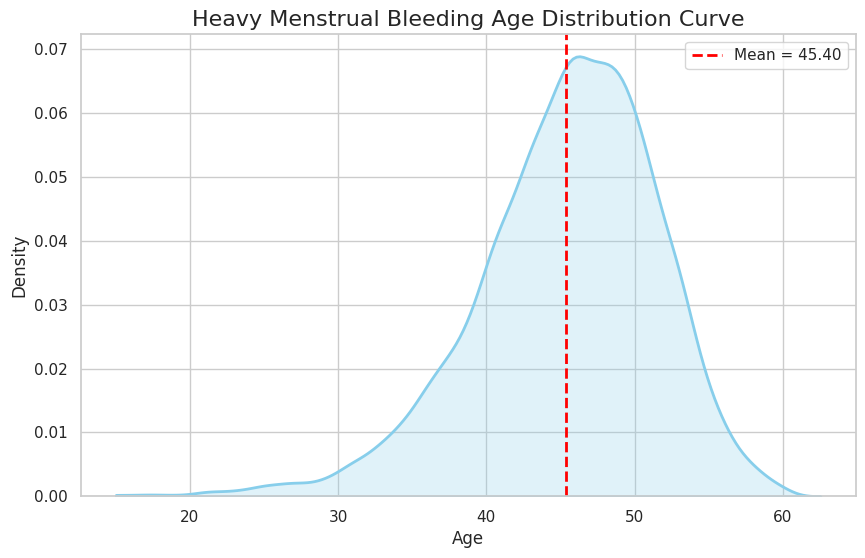

In [59]:
sns.set_theme(style="whitegrid")  
plt.figure(figsize=(10, 6))  

# calculate average diagnosis age and plot age distribution curve
avg_diagnosis_age = hmb_phenotype_df.filter(F.col('diagnosis_age').isNotNull()).agg(F.avg('diagnosis_age')).collect()[0][0]
sns.kdeplot(filtered_ages, fill=True, clip=(15, 70), color='skyblue', linewidth=2)
plt.axvline(avg_diagnosis_age, color='red', linestyle='--', linewidth=2, label=f"Mean = {avg_diagnosis_age:.2f}")

plt.title("Heavy Menstrual Bleeding Age Distribution Curve", fontsize=16)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()
plt.show()